In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import joblib


### **Load Dataset**


In [2]:
df=pd.read_csv('D:\\Github\\Artificial-Intelligence-Labs\\House Price Predictor\\data\\raw\\AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


### **EDA**


In [3]:
df.shape

(2930, 82)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(10)


Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64

In [8]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

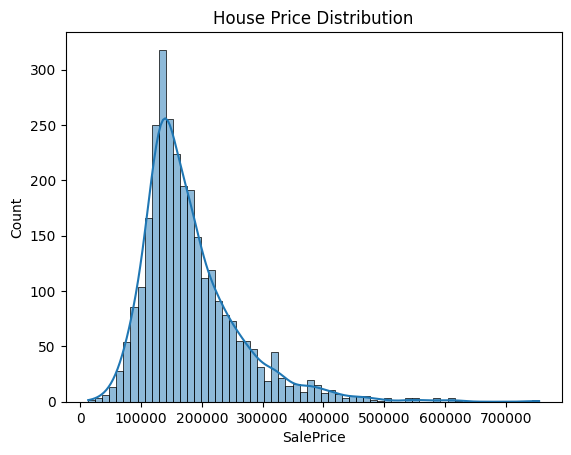

In [ ]:
plt.figure()
sns.histplot(df["SalePrice"],kde=True)
plt.title("House Price Distribution")
plt.show()


### **Co-relation with target**


In [10]:
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr.head(10)


SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64

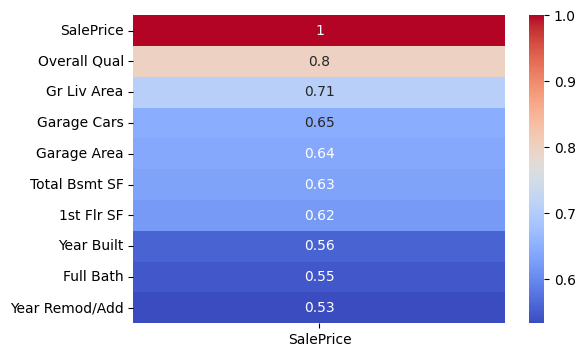

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr.head(10).to_frame(),annot=True, cmap="coolwarm")
plt.show()

### **Feature Selection**
* Selecting Strong Features


In [16]:
features=[
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Total Bsmt SF",
    "Year Built"
]

target="SalePrice"

df_model=df[features + [target]].dropna()
df_model.head()


,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,Year Built,SalePrice
0,6,1656,2.0,1080.0,1960,215000
1,5,896,1.0,882.0,1961,105000
2,6,1329,1.0,1329.0,1958,172000
3,7,2110,2.0,2110.0,1968,244000
4,5,1629,2.0,928.0,1997,189900


### **train/val/test Split**
* 70% Training Data
* 15% Validating Data
* 15% Testing Data


In [17]:
X=df_model[features]
y=df_model[target]

X_train,X_temp,y_train,y_temp=train_test_split(
    X,y,test_size=0.3,random_state=42
)

X_val,X_test,y_val,y_test=train_test_split(
    X_temp,y_temp,test_size=0.5,random_state=42
)


### **Feature Scaling**

* Standarizing Numerical features (Mean = 0, STD = 1), because numerical features have different ranges.
* Scaling is important because large-scale features dominate the model, scaling makes all features contribute same.


In [18]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)


### **Training (Linear Regression)**

In [19]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### **Evaluation**
* Making Predictions on Validation set
* Validation R² = 0.8303 (Good)
* Validation RMSE = 33,049 
* On average, model predictions are off by: ≈ $33,049



In [22]:
y_val_pred=model.predict(X_val_scaled)

r2_val=r2_score(y_val, y_val_pred)
rmse_val=np.sqrt(mean_squared_error(y_val, y_val_pred))

print("Validation R²:",r2_val)
print("Validation RMSE:",rmse_val)


Validation R²: 0.8303770386881837
Validation RMSE: 33049.36613616043


### **Testing**
* Test R² = 0.7664 ( Good )
* Test RMSE = 43,964
* On average, predictions differ from actual price by: ≈ $43,964



In [23]:
y_test_pred=model.predict(X_test_scaled)

r2_test=r2_score(y_test, y_test_pred)
rmse_test=np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Test R²:", r2_test)
print("Test RMSE:", rmse_test)


Test R²: 0.76648414981874
Test RMSE: 43964.81182650934


In [26]:
joblib.dump(model, "D:\\Github\\Artificial-Intelligence-Labs\\House Price Predictor\\models\\model.pkl")
joblib.dump(scaler, "D:\\Github\\Artificial-Intelligence-Labs\\House Price Predictor\\models\\scaler.pkl")


['D:\\Github\\Artificial-Intelligence-Labs\\House Price Predictor\\models\\scaler.pkl']